# Cause Missingness — FPA-FOD 6th Edition

`NWCG_GENERAL_CAUSE` is missing (recorded as `Missing data/not specified/undetermined`) for a
substantial minority of fires, and that missingness is not uniform — it varies by reporting
agency, by geography, over time, and with fire size. Because the project weights cause
composition by burned area, *how* cause goes missing shapes what the attributed signal supports.

This notebook characterizes that missingness: which records lack cause, where they concentrate,
whether the gap is one phenomenon or several, and how exposed the burned-area-weighted product
is to it. Companion to [`02_eda.ipynb`](02_eda.ipynb), on the same `Fires` table.

## Load data

Load the `Fires` table and flag the missing-cause records.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DB_PATH = Path("..") / "data" / "FPA_FOD_20221014.sqlite"

with sqlite3.connect(DB_PATH) as conn:
    cols = pd.read_sql_query("PRAGMA table_info(Fires);", conn)["name"].tolist()
    load_cols = [c for c in cols if c != "Shape"]
    df = pd.read_sql_query(f"SELECT {', '.join(load_cols)} FROM Fires", conn)

MISSING = "Missing data/not specified/undetermined"
df["is_missing"] = df["NWCG_GENERAL_CAUSE"] == MISSING
print(f"{len(df):,} fires; cause missing for {df['is_missing'].mean():.1%} of records.")

2,303,566 fires; cause missing for 26.0% of records.


## How incomplete is cause, next to the other analysis fields?

The spatial and temporal keys are essentially universal; cause is the one analysis variable with
a real gap. Its incompleteness is not a *null* — it lives in the `Missing/undetermined`
**category** — so it is reported as a category share alongside the null rates of its neighbours.

In [2]:
# Completeness of the analysis columns. Cause's Missing/undetermined share is reported as a
# category rate, since cause is never null.
key_cols = ["FIRE_YEAR", "DISCOVERY_DOY", "FIRE_SIZE",
            "STATE", "LATITUDE", "LONGITUDE", "NWCG_GENERAL_CAUSE"]
completeness = (
    df[key_cols].notna().mean()
    .mul(100).round(2)
    .rename("non_null_%")
    .to_frame()
)
completeness.loc["NWCG_GENERAL_CAUSE", "note"] = (
    f"{df['is_missing'].mean()*100:.1f}% in Missing/undetermined category"
)
completeness

,non_null_%,note
FIRE_YEAR,100.0,NaN
DISCOVERY_DOY,100.0,NaN
FIRE_SIZE,100.0,NaN
STATE,100.0,NaN
LATITUDE,100.0,NaN
LONGITUDE,100.0,NaN
NWCG_GENERAL_CAUSE,100.0,26.0% in Missing/undetermined category


## Is missingness one phenomenon, or several?

**Hypothesis.** If missing cause is uniform case-by-case "cause could not be determined," the
rate should be similar across reporting agencies and states. If it clusters in particular
sources, that points to reporting practice rather than case-by-case uncertainty.

**Experiment.** Three cuts: overall scale (counts vs acres), by reporting agency, and by state.

In [3]:
# Overall scale: missing rate by count vs. by burned acres.
count_rate = df["is_missing"].mean()
acre_rate = df.loc[df["is_missing"], "FIRE_SIZE"].sum() / df["FIRE_SIZE"].sum()
print(f"Missing-cause rate by count: {count_rate:.1%}")
print(f"Missing-cause rate by acres: {acre_rate:.1%}")
print("-> missing-cause fires skew smaller than average (acre rate < count rate).")

Missing-cause rate by count: 26.0%
Missing-cause rate by acres: 18.7%
-> missing-cause fires skew smaller than average (acre rate < count rate).


### Missing rate by reporting agency

`NWCG_REPORTING_AGENCY` identifies who submitted each record.

In [4]:
agency_rates = (
    df.groupby("NWCG_REPORTING_AGENCY")
    .agg(n=("is_missing", "size"), miss_rate=("is_missing", "mean"))
    .sort_values("n", ascending=False)
)
agency_rates["miss_rate"] = (agency_rates["miss_rate"] * 100).round(1)
agency_rates

,n,miss_rate
NWCG_REPORTING_AGENCY,,
ST/C&L,1728168,29.0
FS,250995,9.1
BIA,138996,14.8
BLM,113672,17.6
NPS,23599,18.2
IA,21853,99.8
FWS,21331,30.4
TRIBE,4737,6.3
DOD,163,86.5


**Finding.** The rate varies sharply by source. `ST/C&L` (state/county/local — 1.7M of 2.3M
rows) sits at ~29%; federal land-management agencies (`FS`, `BIA`, `BLM`, `NPS`, `TRIBE`) run
6–18%.

`IA` is the outlier: 21,853 rows at a **99.8%** missing rate — essentially every `IA`-reported
fire has no cause. That is ~1% of all rows and extreme enough to identify directly rather than
fold into "some agencies report cause less reliably."

### What is the `IA` stream?

In [5]:
ia = df.loc[df["NWCG_REPORTING_AGENCY"] == "IA"]
print("IA rows by state:")
print(ia["STATE"].value_counts().head())
print("\nIA rows by owner:")
print(ia["OWNER_DESCR"].value_counts().head())
print(f"\nIA fire-year range: {ia['FIRE_YEAR'].min()}-{ia['FIRE_YEAR'].max()}")

IA rows by state:
STATE
PR    21802
CO       22
WY       17
AZ        3
MT        2
Name: count, dtype: int64

IA rows by owner:
OWNER_DESCR
MISSING/NOT SPECIFIED    21815
COUNTY                      25
PRIVATE                      6
USFS                         6
UNDEFINED FEDERAL            1
Name: count, dtype: int64

IA fire-year range: 2000-2020


**Finding.** `IA` is almost entirely Puerto Rico (21,802 of 21,853 rows), 2000–2020, with
`OWNER_DESCR = 'MISSING/NOT SPECIFIED'` for nearly all of them. This is not case-by-case
undetermined cause — it is a reporting stream that does not carry cause attribution at all.

### Missing rate by state

Checking whether the same pattern appears geographically, on states with n > 1,000.

In [6]:
state_rates = (
    df.groupby("STATE")
    .agg(n=("is_missing", "size"), miss_rate=("is_missing", "mean"))
)
state_rates = state_rates.loc[state_rates["n"] > 1000]
state_rates["miss_rate"] = (state_rates["miss_rate"] * 100).round(1)
state_rates.sort_values("miss_rate", ascending=False).head(15)

,n,miss_rate
STATE,,
PR,22202,98.7
HI,9970,98.1
CT,6714,61.6
NY,99142,54.3
IA,5672,49.2
CO,68629,46.6
IL,3022,42.5
KS,18576,41.5
AZ,104956,41.0


**Finding.** **Puerto Rico (98.7%) and Hawaii (98.1%) are not differentially missing — they are
functionally unattributed.** Almost no fire in either carries a cause. Several CONUS states are
also high (NY 54%, CO 47%, KS 41%, AZ 41%, CA 38%), so there is a real gradient beyond PR/HI, but
those two are categorically different: at that rate no usable cause signal remains.

### Does the post-2010 rise hold without PR/HI?

**Hypothesis.** The missing-cause share climbs after ~2010. Since PR/HI are near-total
non-reporters, they could be manufacturing that trend by entering the database more heavily in
later years.

**Experiment.** Recompute the national trend with PR/HI excluded and compare.

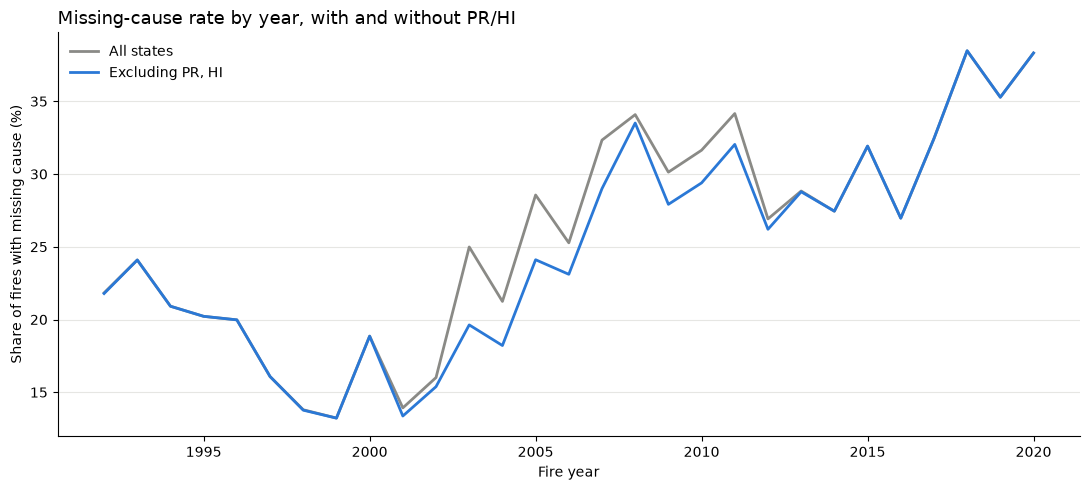

In [7]:
all_states = df.groupby("FIRE_YEAR")["is_missing"].mean() * 100
excl_pr_hi = (
    df.loc[~df["STATE"].isin(["PR", "HI"])].groupby("FIRE_YEAR")["is_missing"].mean() * 100
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(all_states.index, all_states.values, color="#8a8a86", lw=2, label="All states")
ax.plot(excl_pr_hi.index, excl_pr_hi.values, color="#2a78d6", lw=2,
        label="Excluding PR, HI")
ax.set_title("Missing-cause rate by year, with and without PR/HI", fontsize=13, loc="left")
ax.set_ylabel("Share of fires with missing cause (%)")
ax.set_xlabel("Fire year")
ax.legend(frameon=False, loc="upper left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Finding.** The lines track closely — PR/HI are too small a share of national fire volume to
drive the post-2010 rise. **The rise is a real pattern in the CONUS/federal data itself.**

Taken together, the three cuts show missingness is **not one phenomenon**. `ST/C&L`'s ~29% looks
like genuine case-by-case "cause could not be determined." `IA`/Puerto Rico's 99.8% looks like a
reporting stream that never carried cause data. These need different handling, and **PR, HI and
`IA` are candidates for exclusion rather than caveat**.

*Why* `ST/C&L` reporting or the post-2010 national rate moved would need attribution-practice
documentation outside FPA-FOD, so it stays out of scope.

## Apply the exclusion: drop PR/HI/IA

`IA` is a reporting stream that never carried cause (99.8% missing, almost entirely Puerto Rico);
PR (98.7%) and HI (98.1%) are functionally unattributed. None contributes usable cause signal to
weight by burned area, so from here the notebook works on the **attributed record** with them
removed — matching the cleaning rule `drop STATE in ('PR','HI') OR NWCG_REPORTING_AGENCY == 'IA'`.

Cells above this point stay on raw data: they are the diagnosis that establishes the drop. Cells
below run on the reduced frame, which lets the remaining question — the shape of *ordinary*
case-by-case missingness — be studied without two whole non-reporting streams drowning it out.
The drop also removes ~51 stray non-PR `IA` rows that earlier inline PR/HI filters never caught.

In [8]:
# From here down, `df` is the attributed record. Cells above stay on the raw frame.
n_before = len(df)
drop_mask = df["STATE"].isin(["PR", "HI"]) | (df["NWCG_REPORTING_AGENCY"] == "IA")
df = df.loc[~drop_mask].copy()

reduced_acre_rate = (df.loc[df["is_missing"], "FIRE_SIZE"].sum()
                     / df["FIRE_SIZE"].sum())
print(f"Dropped {n_before - len(df):,} rows "
      f"(PR/HI or IA); {len(df):,} remain ({len(df)/n_before:.1%} of raw).")
print(f"Missing-cause rate on the reduced frame: {df['is_missing'].mean():.1%} by count, "
      f"{reduced_acre_rate:.1%} by acres (was 26.0% / 18.7% on raw).")

Dropped 32,223 rows (PR/HI or IA); 2,271,343 remain (98.6% of raw).
Missing-cause rate on the reduced frame: 24.9% by count, 18.5% by acres (was 26.0% / 18.7% on raw).


## Where did the missing-cause rise concentrate?

The characterization above left one thread open: the missing-cause share climbs after
~2010, and it isn't a PR/HI artifact — so *where* in the data does the rise sit? If cause
attribution were a single national standard applied uniformly, a rise would show up
roughly evenly across the agencies that report fires. If instead it reflects uneven
reporting practice — different agencies, resourcing, or record-keeping changing at
different times — the rise should **concentrate** in some reporting streams and not
others.

This is a descriptive question the data can answer: decompose the trend by
**reporting agency × year** and by **region × year**. It stays on the observable side —
*that* the rise is uneven, and *where* it sits — without asserting *why* (priorities,
resources, governance are administrative explanations FPA-FOD doesn't record; they remain
labeled hypotheses, per the project's no-policy-assumptions constraint).

Four reporting agencies carry enough fires in every year to support a per-year rate:
`ST/C&L` (state/county/local), `FS` (Forest Service), `BIA` (Bureau of Indian Affairs),
and `BLM` (Bureau of Land Management). Smaller agencies are dropped from the trend to
avoid noisy per-year rates.

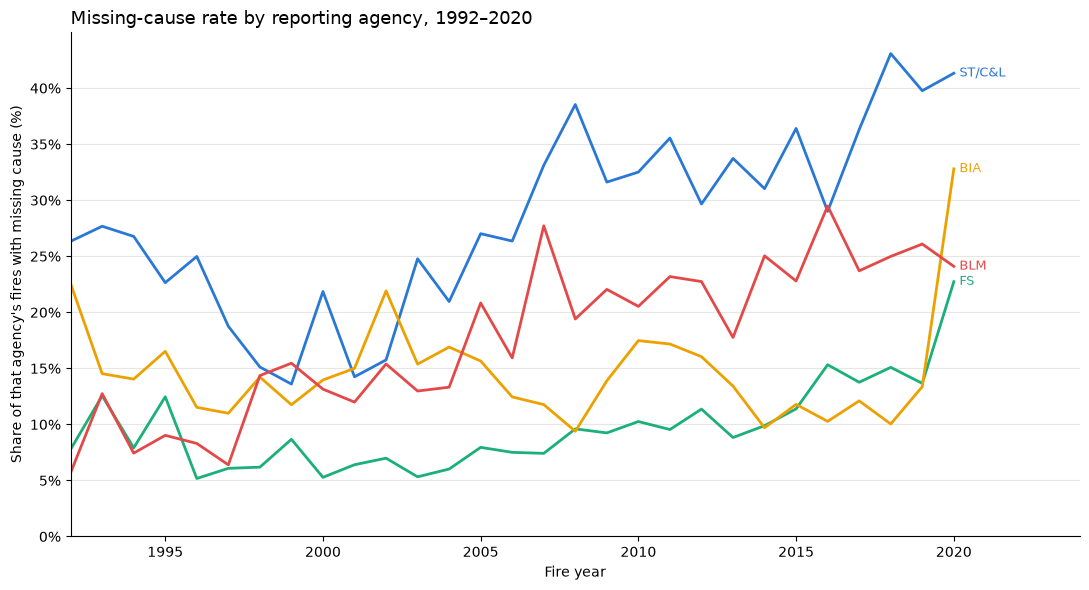

In [9]:
# Missing-cause rate per reporting agency per year (is_missing defined in the
# characterization section above). Restrict to agencies with enough per-year volume.
BIG_AGENCIES = ["ST/C&L", "FS", "BIA", "BLM"]

agency_year = (
    df[df["NWCG_REPORTING_AGENCY"].isin(BIG_AGENCIES)]
    .groupby(["FIRE_YEAR", "NWCG_REPORTING_AGENCY"])["is_missing"]
    .mean()
    .unstack()
    * 100
)

# Distinct hues (identity, not order) reusing the project base palette.
agency_colors = dict(zip(BIG_AGENCIES, ["#2a78d6", "#1baf7a", "#eda100", "#e34948"]))

fig, ax = plt.subplots(figsize=(11, 6))
for a in BIG_AGENCIES:
    ax.plot(agency_year.index, agency_year[a], color=agency_colors[a], lw=2)
    ax.annotate(a, (agency_year.index.max(), agency_year[a].iloc[-1]),
                xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=agency_colors[a])
ax.set_title("Missing-cause rate by reporting agency, 1992–2020", fontsize=13, loc="left")
ax.set_ylabel("Share of that agency's fires with missing cause (%)")
ax.set_xlabel("Fire year")
ax.set_xlim(agency_year.index.min(), agency_year.index.max() + 4)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(bottom=0)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The rise is **not uniform across reporting agencies** — which is the whole point. Comparing
each agency's early-period rate (1992–1996) to its late-period rate (2016–2020):

- **`BLM`** climbs the most, from ~9% to ~26% (roughly +17 points).
- **`ST/C&L`** — the dominant stream, 1.7M of 2.3M fires — rises from ~26% to ~38% (+12).
- **`FS`** rises modestly, ~9% to ~16% (+7).
- **`BIA`** is essentially **flat** (~16% throughout).

A single national attribution standard applied uniformly would not produce one agency
holding flat while another nearly triples. The unevenness is consistent with
**reporting practice differing by agency and shifting at different times** — but the data
shows the *pattern*, not the cause. Whether the divergence reflects resourcing, changing
record systems, or something else is not recoverable from FPA-FOD and stays a hypothesis.

Because `ST/C&L` both dominates the volume and rises substantially, it drives most of the
national trend seen earlier — so the national rise is largely a state/county/local
reporting story, not a federal-lands one.

### Does the rise track Natural-dominated regions?

The agency view says *who's* driving the rise; this asks *where*, at the project's actual
region grain — the **EPA Level III ecoregion**. It bears directly on the absorption thread
from `02_eda.ipynb`'s Natural deep-dive: if the missing-cause rise were fires that would once
have been labeled *Natural* slipping into the Missing bucket, the rise should concentrate in
**Natural-dominated ecoregions**. If instead it's a broad reporting shift, the rise should
appear regardless of an ecoregion's Natural share.

Ecoregion labels come from a points→ecoregion spatial join, cached by
`cause_density_maps.load_conus_points()` (the same loader behind the density maps, now
carrying `FIRE_YEAR` and the joined `US_L3NAME`). The first call builds the cache; later
runs load it. AK/HI/PR fall outside the CONUS ecoregion layer and are dropped by the join
— which also removes the near-unusable PR/HI cause data as a side effect.

For each ecoregion with enough fires, we plot the change in missing rate from the early
half (1992–2005) to the late half (2006–2020) against that ecoregion's overall Natural-fire
share. **Absorption predicts an upward-sloping cloud** — the missing rate rising most where
Natural fire dominates. A **broad reporting shift predicts no such slope** — the rise
appearing regardless of Natural share. Read the *shape*, not just the correlation: a Pearson
*r* near zero can hide structure (a slope in only part of the range, or spread that changes
across it), so the scatter itself is the honest artifact.

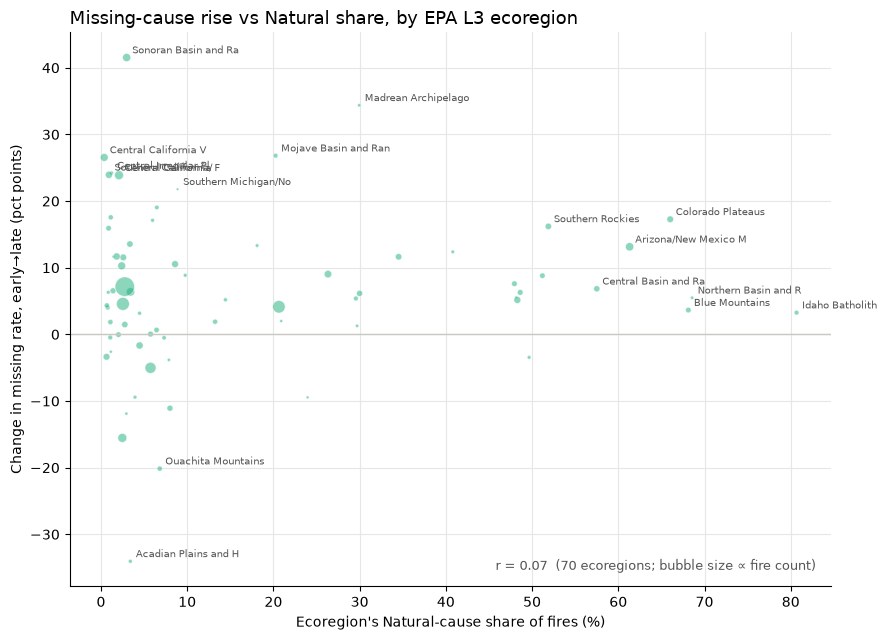

In [10]:
import sys

# Reuse the density-map loader: it spatial-joins fires to EPA L3 ecoregions and
# caches the result (cause + FIRE_YEAR + US_L3NAME + geometry). First run builds
# the cache; later runs load it.
sys.path.insert(0, str(Path("..") / "src"))
from cause_density_maps import load_conus_points

geo_conus, _ = load_conus_points()

# Per-ecoregion: change in missing rate (early half -> late half) vs Natural share.
# (Points already CONUS-only; PR/HI dropped by the ecoregion join.)
eco_pts = geo_conus[["NWCG_GENERAL_CAUSE", "FIRE_YEAR", "US_L3NAME"]].copy()
eco_pts["is_missing"] = eco_pts["NWCG_GENERAL_CAUSE"] == MISSING
eco_pts["is_natural"] = eco_pts["NWCG_GENERAL_CAUSE"] == "Natural"
eco_pts["era"] = np.where(eco_pts["FIRE_YEAR"] <= 2005, "early", "late")

by_eco = eco_pts.groupby("US_L3NAME")
eco_tbl = pd.DataFrame({
    "n": by_eco.size(),
    "nat_share": by_eco["is_natural"].mean() * 100,
})
era_rate = eco_pts.pivot_table(index="US_L3NAME", columns="era",
                               values="is_missing", aggfunc="mean") * 100
eco_tbl["delta_missing"] = era_rate["late"] - era_rate["early"]
# Require enough fires overall AND in each era for a stable early/late rate.
era_n = eco_pts.pivot_table(index="US_L3NAME", columns="era",
                            values="is_missing", aggfunc="size")
eco_tbl = eco_tbl[(eco_tbl["n"] > 5000)
                  & (era_n["early"] > 500) & (era_n["late"] > 500)].dropna()

r = eco_tbl["delta_missing"].corr(eco_tbl["nat_share"])

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(eco_tbl["nat_share"], eco_tbl["delta_missing"],
           s=eco_tbl["n"] / 1500, color="#1baf7a", alpha=0.5,
           edgecolor="white", linewidth=0.6)
# Label the biggest movers (either direction) and the most Natural-dominated regions.
big_move = eco_tbl["delta_missing"].abs() > 20
high_nat = eco_tbl["nat_share"] > eco_tbl["nat_share"].quantile(0.9)
for name, row in eco_tbl[big_move | high_nat].iterrows():
    ax.annotate(name[:20], (row["nat_share"], row["delta_missing"]),
                xytext=(4, 3), textcoords="offset points", fontsize=7, color="#555")
ax.axhline(0, color="#c9c8c3", lw=1)
ax.set_title("Missing-cause rise vs Natural share, by EPA L3 ecoregion",
             fontsize=13, loc="left")
ax.set_xlabel("Ecoregion's Natural-cause share of fires (%)")
ax.set_ylabel("Change in missing rate, early→late (pct points)")
ax.annotate(f"r = {r:.2f}  ({len(eco_tbl)} ecoregions; bubble size ∝ fire count)",
            (0.98, 0.03), xycoords="axes fraction", ha="right", fontsize=9, color="#555")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The cloud is neither a clear upward slope nor a flat band — r ≈ 0.07, but the shape carries
more than that number. Two features stand out:

**Low-Natural (human-dominated) ecoregions scatter both ways.** On the left, ecoregions
spread across a wide −20 to +27 band, with the extremes keeping identities: Acadian Plains
(≈−34) and Ouachita Mountains (≈−20) falling, Sonoran Basin (≈+41) and the Central
California Valley cluster (≈+24) rising. There's no consistent direction here — some
human-dominated ecoregions saw their missing rate climb sharply, others saw it drop just as
sharply.

**High-Natural ecoregions drift modestly, and consistently, up.** On the right (>50%
Natural), every ecoregion sits **positive** — Colorado Plateaus (≈+17), Southern Rockies
(≈+16), Arizona/New Mexico Mountains (≈+13), plus Northern Basin, Blue Mountains, and Idaho
Batholith around +3 to +9. Crucially, there are **no high-Natural ecoregions with a large
negative delta**: the downward movers are all human-dominated. So the missing rate rose,
mildly but without exception, everywhere Natural fire dominates.

**What this means for the absorption (Natural → Missing) question.** The result is
**weakly consistent with absorption, but not evidence for it:**

- The consistent upward drift in Natural-dominated ecoregions — and the *absence* of
  offsetting declines there — is the **direction absorption predicts**: if Natural fires were
  increasingly relabeled Missing, the western Natural regions are exactly where a rising
  missing rate should appear, and it does.
- But the effect is **small** (+3 to +17 points, against the ±30–40 swings among
  human-dominated ecoregions), and a modest missing-rate rise in the West is **equally
  explained by a general reporting decline** touching those regions along with everywhere
  else. A rising missing rate alone can't separate "Natural fires being relabeled" from "all
  causes going unrecorded a bit more often."
- So the scatter **neither confirms nor rules out** modest Natural-relabeling in the West.
  The large, two-directional swings among human-dominated ecoregions are a separate story —
  reporting practice churning at the local level, which absorption doesn't explain and
  doesn't need to.

**For the project.** The operating conclusion is that the missing-cause trend is best treated
as a **reporting-completeness / data-quality phenomenon** — so model cause as **shares within
attributed fires** rather than trusting raw counts. Whether a *modest* Natural-relabeling
also operates in the West is left open. If resolving it matters — it bears on whether the
Natural large-fire tail trend from the deep-dive is real or a labeling artifact — the direct
test is to track **Natural count vs. Missing count over time *within* the high-Natural western
ecoregions**: absorption predicts the two move as mirror images there. That's a targeted
follow-up, not something this scatter settles.

## Does fire size predict whether cause is recorded?

**Hypothesis.** On the reduced frame cause is missing for **24.9% of fires but only ~18.5% of
burned acres**, so missing-cause fires skew smaller. If the largest fires are the best attributed,
the missing-cause problem is mildest exactly where burned-area weighting puts the most weight.

**Experiment.** Missing rate across fixed log-spaced size bins on the reduced frame, plus the rate
in the large-fire tail specifically.

Sub-0.01-acre records excluded from the curve: 3,625 (0.16% of fires), 80% missing.


/var/folders/hr/t1_4y5dd3nqgxcj6kn65dgdm0000gn/T/ipykernel_78424/3491862817.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


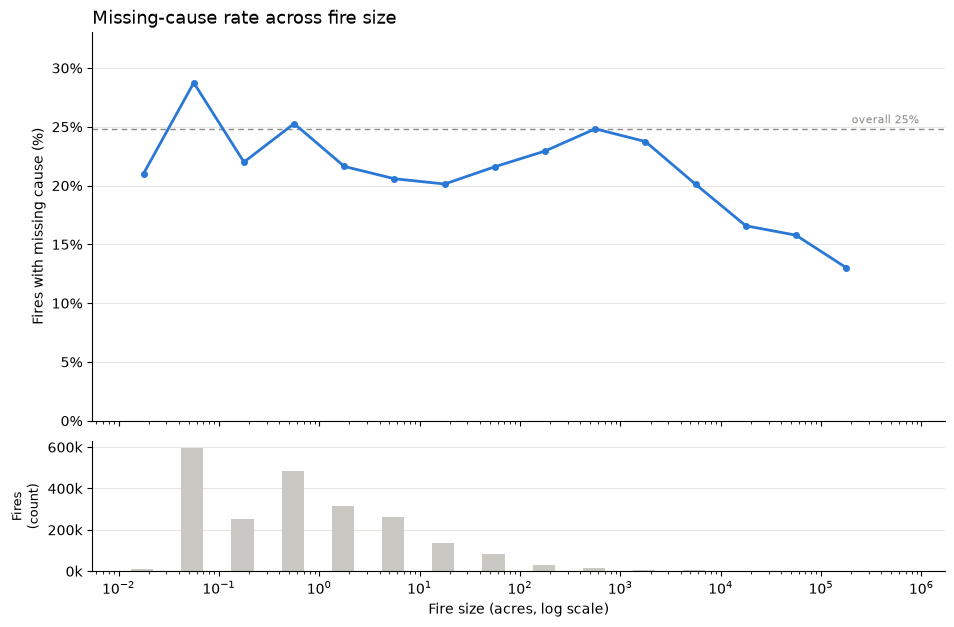

In [11]:
# Missing rate across fire size, on fixed log-spaced size bins.
size_df = df[["FIRE_SIZE", "is_missing"]].copy()

# ~3,600 fires (<0.16%) sit below 0.01 ac — mostly the value 0.001, a placeholder-looking
# size well under the FPA-FOD Class A floor (0.25 ac) — and are ~80% missing. Reported
# separately so a degenerate bin doesn't distort the left end; the curve starts at 0.01 ac.
micro = size_df[size_df["FIRE_SIZE"] < 0.01]
size_df = size_df[size_df["FIRE_SIZE"] >= 0.01]
print(f"Sub-0.01-acre records excluded from the curve: {len(micro):,} "
      f"({len(micro)/(len(size_df)+len(micro)):.2%} of fires), "
      f"{micro['is_missing'].mean()*100:.0f}% missing.")

# Half-decade log bins from 0.01 ac up to just past the max (~6.6e5 ac).
edges = np.logspace(-2, 6, 17)
size_df["bin"] = pd.cut(size_df["FIRE_SIZE"], bins=edges)
grp = size_df.groupby("bin", observed=True)
rate = grp["is_missing"].mean() * 100
n = grp.size()
centers = np.sqrt([iv.left * iv.right for iv in rate.index])  # geometric bin center

# Suppress bins too thin for a stable rate; keep them in the count panel so the thinness shows.
STABLE = n.values >= 100
overall = size_df["is_missing"].mean() * 100  # national reference line

fig, (ax, axn) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True,
    gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08),
)

ax.axhline(overall, color="#8a8a86", lw=1, ls=(0, (4, 3)))
ax.annotate(f"overall {overall:.0f}%", (centers[STABLE][-1], overall), xytext=(4, 2),
            textcoords="offset points", fontsize=8, color="#8a8a86", va="bottom")
ax.plot(centers[STABLE], rate.values[STABLE], color="#2a78d6", lw=2, marker="o", ms=4)
ax.set_title("Missing-cause rate across fire size", fontsize=13, loc="left")
ax.set_ylabel("Fires with missing cause (%)")
ax.set_ylim(0, max(rate.values[STABLE].max() * 1.15, overall * 1.2))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

axn.bar(centers, n.values, width=centers * 0.5, color="#c9c8c3")
axn.set_ylabel("Fires\n(count)", fontsize=9)
axn.set_xlabel("Fire size (acres, log scale)")
axn.set_xscale("log")
axn.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:g}k"))

for a in (ax, axn):
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(axis="y", color="#e6e6e3", lw=0.8)
    a.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [12]:
# The tail: the largest fires carry the most acres, so their missing rate is what the
# burned-area-weighted view leans on.
print(f"{'threshold':>14}   {'n fires':>8}   miss rate")
for thr in [0.1, 1, 100, 1000, 10000, 100000]:
    sub = size_df[size_df["FIRE_SIZE"] >= thr]
    print(f"{'>= ' + format(thr, ',g') + ' ac':>14}   {len(sub):>8,}   {sub['is_missing'].mean()*100:5.1f}%")

# Reconcile with the headline: missing share of COUNT vs of ACRES.
miss_count = size_df["is_missing"].mean() * 100
miss_acres = (size_df.loc[size_df["is_missing"], "FIRE_SIZE"].sum()
              / size_df["FIRE_SIZE"].sum()) * 100
print(f"\nMissing share of fire COUNT: {miss_count:.1f}%")
print(f"Missing share of burned ACRES: {miss_acres:.1f}%")
print("-> acres < count because the acre total is tail-driven, and the tail is "
      "better-attributed.")

     threshold    n fires   miss rate
     >= 0.1 ac   2,166,164    24.3%
       >= 1 ac   1,119,699    22.7%
     >= 100 ac     65,192    23.6%
   >= 1,000 ac     14,372    21.8%
  >= 10,000 ac      2,816    16.4%
 >= 100,000 ac        244    14.8%

Missing share of fire COUNT: 24.8%
Missing share of burned ACRES: 18.5%
-> acres < count because the acre total is tail-driven, and the tail is better-attributed.


**Finding.** Missingness does **not** rise smoothly as fires shrink. The curve has three regimes:

- **Smallest fires (~0.03–0.1 ac): ~29% missing**, above the ~25% average. The excess persists
  *within* the dominant `ST/C&L` stream, so it is a real size effect, not an artifact of which
  regions report tiny fires.
- **The broad middle (~0.1 to a few thousand acres): a ~20–25% band with no trend.** Across roughly
  four orders of magnitude, size carries almost no information about whether cause is recorded.
- **The large-fire tail (≥ ~10,000 ac): the rate drops to ~13–16%.** ≥10,000 ac is 16.4% missing;
  ≥100,000 ac just 14.8%. Large fires get investigated.

**Why the aggregate reads "missing skews small."** The count-weighted rate (≈25%) is lifted by the
sheer number of small fires. The acre-weighted rate (≈19%) is pulled down because acres are
tail-driven and the tail is the best-attributed part of the record. The gap between the two
headline numbers is a **small-fire excess and a large-fire deficit** acting on very
differently-weighted denominators, not a smooth size gradient.

**This is favourable for the burned-area-weighted product.** The deliverable ranks causes by acres,
which large fires dominate, and those are where cause is most complete. It does not license
ignoring missingness — a ~15% tail rate is real and geographically uneven — but the acre-weighted
view is materially less exposed than a count-weighted one.

## Does the Missing bucket hide particular causes?

Every section above tests missingness against a *predictor* — agency, geography, year, fire size —
and finds it uneven on all of them. This section asks the narrower question about the *target*:
**is `Missing/undetermined` a roughly random sample of the true cause mix (a pure data-quality
gap), or does it disproportionately hide particular causes** — Natural above all — which would
bias the burned-area-weighted composition even after weighting?

The true cause of a Missing record is unobserved, so there is no direct test: you cannot
cross-tabulate Missing against the field that is missing. Three indirect probes instead look for
the footprints a *non*-random draw would leave in the attributed record:

- **Over time** — do attributed shares move against the missing rate, year to year?
- **Within region×season** — does a cause's share fall as local missingness rises, holding place
  and season fixed?
- **By fire size** — do small and large fires have different cause mixes, so that concentrating
  missingness in small fires also concentrates it in whatever small fires tend to be?

All three run on the reduced frame (PR/HI/IA dropped). Individually each is weak; a consistent
answer across all three is more than any one.

### Over time — do attributed shares move against the missing rate?

**Hypothesis.** If the bucket draws randomly across causes, cause shares among attributed fires
stay flat as the missing rate climbs. If it preferentially hides one cause, that cause's share
sags in exactly the years the missing rate rises.

**Experiment.** The missing rate per year beside the attributed-only share of each cause per year.

A raw correlation between the two is a trap: both series drift with the calendar, so *any*
trending cause correlates with the (also trending) missing rate regardless of mechanism. The
numeric test therefore **detrends both series** — removing each cause's and the missing rate's
linear time trend — and correlates the residuals, asking whether in years missingness jumped
*above its own trend*, a cause's share dipped *below its own trend*. The table reports the raw
slope, the raw correlation and the detrended correlation side by side.

**Detrending erases gradual absorption.** If Missing slowly ate one cause across all 29 years, that
signal lives in the trend and is removed. This probe rules out *year-to-year* selective hiding, not
slow drift — which is what the within-region×season probe is for.

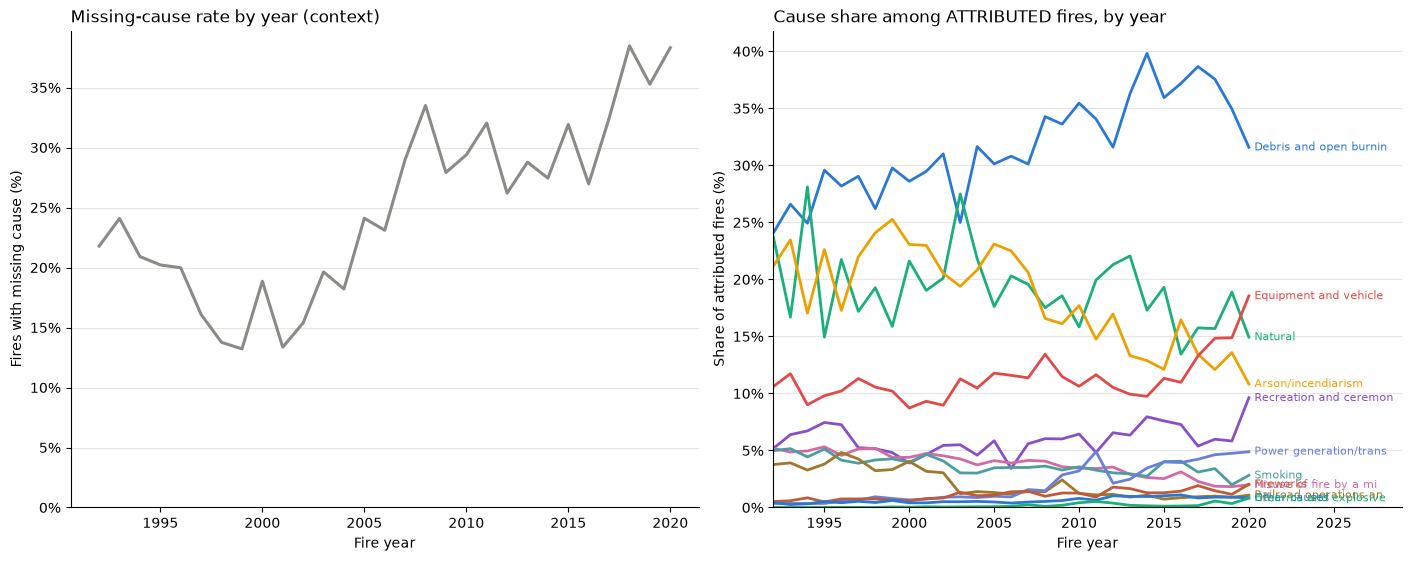

Each cause's attributed share vs. the yearly missing rate (29 yearly points; descriptive, not a significance test):
  trend_slope_pp/yr = share's own linear trend (pct points per year)
  raw_r             = corr(share, missing rate)      <- TRAP: driven by shared drift
  detrended_r       = corr of residuals after detrend <- the sharper read

                                            trend_slope_pp/yr  raw_r  detrended_r
Debris and open burning                                  0.42   0.65        -0.07
Natural                                                 -0.16  -0.32        -0.02
Arson/incendiarism                                      -0.40  -0.83        -0.52
Equipment and vehicle use                                0.15   0.74         0.54
Recreation and ceremony                                  0.05   0.46         0.33
Misuse of fire by a minor                               -0.12  -0.82        -0.32
Smoking                                                 -0.07  -0.55         0.18

In [13]:
# Attributed-only cause shares per year, beside the missing rate per year.
# "Attributed" = every record whose cause is not Missing.
attributed = df[~df["is_missing"]]

# Share of each cause among attributed fires, per year (rows sum to 100% within a year).
cause_year = (
    attributed.groupby(["FIRE_YEAR", "NWCG_GENERAL_CAUSE"]).size()
    .unstack(fill_value=0)
)
cause_share = cause_year.div(cause_year.sum(axis=1), axis=0) * 100
miss_year = df.groupby("FIRE_YEAR")["is_missing"].mean() * 100

# Order causes by overall attributed volume; stable identity hue per cause.
cause_order = attributed["NWCG_GENERAL_CAUSE"].value_counts().index.tolist()
base_hues = ["#2a78d6", "#1baf7a", "#eda100", "#e34948", "#8a4fc4",
             "#d16ba5", "#4a9e9e", "#a0782a", "#6a7fdb", "#c05b3a"]
cause_colors = {c: base_hues[i % len(base_hues)] for i, c in enumerate(cause_order)}

# constrained_layout, not tight_layout: the two panels have different y-scales.
fig, (axm, axc) = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained")

# Left: missing rate per year (the trend the shares are read against).
axm.plot(miss_year.index, miss_year.values, color="#8a8a86", lw=2.2)
axm.set_title("Missing-cause rate by year (context)", fontsize=12, loc="left")
axm.set_ylabel("Fires with missing cause (%)")
axm.set_xlabel("Fire year")
axm.set_ylim(bottom=0)
axm.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

# Right: attributed-only cause shares per year.
for c in cause_order:
    axc.plot(cause_share.index, cause_share[c], color=cause_colors[c], lw=2)
    axc.annotate(c[:22], (cause_share.index.max(), cause_share[c].iloc[-1]),
                 xytext=(4, 0), textcoords="offset points",
                 va="center", fontsize=8, color=cause_colors[c])
axc.set_title("Cause share among ATTRIBUTED fires, by year", fontsize=12, loc="left")
axc.set_ylabel("Share of attributed fires (%)")
axc.set_xlabel("Fire year")
axc.set_xlim(cause_share.index.min(), cause_share.index.max() + 9)
axc.set_ylim(bottom=0)
axc.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

for a in (axm, axc):
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(axis="y", color="#e6e6e3", lw=0.8)
    a.set_axisbelow(True)
plt.show()

# Raw slope, raw correlation, and detrended correlation. Raw corr(share, missing rate) is
# dominated by shared calendar drift; detrending removes each series' linear time trend and
# correlates the residuals, so it asks whether the year-to-year wobbles co-move.
yrs = miss_year.index.values.astype(float)

def _resid(y):
    # residuals of y after removing its own least-squares line in year
    b, a = np.polyfit(yrs, y, 1)
    return y - (b * yrs + a), b   # (residual series, slope per year)

miss_resid, _ = _resid(miss_year.values)

rows = {}
for c in cause_order:
    share_resid, slope = _resid(cause_share[c].values)
    raw_r = np.corrcoef(cause_share[c].values, miss_year.values)[0, 1]
    # detrended r is undefined if a residual series is constant (flat share) -> nan
    det_r = (np.corrcoef(share_resid, miss_resid)[0, 1]
             if share_resid.std() > 0 else np.nan)
    rows[c] = {"trend_slope_pp/yr": slope, "raw_r": raw_r, "detrended_r": det_r}

test1 = pd.DataFrame(rows).T.reindex(cause_order).round(2)
print("Each cause's attributed share vs. the yearly missing rate "
      "(29 yearly points; descriptive, not a significance test):")
print("  trend_slope_pp/yr = share's own linear trend (pct points per year)")
print("  raw_r             = corr(share, missing rate)      <- TRAP: driven by shared drift")
print("  detrended_r       = corr of residuals after detrend <- the sharper read\n")
print(test1.to_string())
print("\n-> Read detrended_r, not raw_r. Strongly negative detrended_r = that cause's share "
      "dips\n   in the years missingness spikes above trend (candidate for year-to-year "
      "hiding);\n   detrended_r near zero across causes = consistent with a random draw "
      "year-to-year\n   (does NOT rule out gradual absorption -- that is Test 2's job).")


**Finding.** **Natural is −0.02 — flat.** At the year-to-year grain there is no sign the bucket
swallows would-be Natural fires.

**The raw correlation is confirmed as a trap.** Nearly every large `raw_r` collapses once shared
calendar drift is removed: Smoking −0.55 → +0.18, Railroad −0.70 → −0.01, Fireworks +0.67 → −0.01,
Debris +0.65 → −0.07. Those raw values were "this cause trends and so does the missing rate" — no
information about hiding.

**Direction is the whole test.** Hiding predicts a *negative* detrended r:

- **Positive** (share moves *with* the missing rate, the opposite of hiding): Equipment +0.54,
  Power generation +0.40, Firearms +0.40, Recreation +0.33.
- **Negative** (the hiding direction): **Arson −0.52** stands alone, then Misuse-by-minor −0.32 and
  Other −0.21; the rest hug zero.

Arson at −0.52 is the fingerprint of arson being pushed into "undetermined," which is
mechanistically plausible — arson is the hardest cause to positively establish, so it is the first
to become undetermined when attribution effort falls.

**How far this goes.** 29 yearly points, 12 compositional causes whose shares sum to 100%, and a
descriptive association rather than a significance test. Detrending also erased any gradual
absorption. Net: broadly consistent with a cause-neutral data-quality gap, with Arson the one cause
worth checking structurally.

### Within region×season — does a cause's share fall as local missingness rises?

**Hypothesis.** Some region-seasons both miss more cause *and* genuinely have a different cause
mix, so a raw cross-cell correlation would confound selective hiding with real geographic
variation. Holding the cell fixed removes that: within one region×season, a cell missing more
cause should show the same attributed composition as a similar cell missing less — unless the
bucket preferentially hides a cause, in which case that cause's share is lower in the
higher-missing cells.

**Experiment.** Within each state×season cell, correlate the cell's missing rate against each
cause's share of the cell's attributed fires **across that cell's years**, then aggregate the
within-cell correlations. Using year as the within-cell variation is what makes this a *within*
test: region and season are constant inside every correlation.

Region grain is **STATE** here — available directly on the reduced frame at full N, no spatial join
— as a stand-in for the project's ecoregion grain. The point is holding *a* region fixed, not
producing the region product.

Unlike the time probe this is **not detrended**, so gradual within-cell drift is preserved. This is
the probe for slow Natural→Missing absorption.

In [14]:
# Within each state x season cell, correlate the missing rate against each cause's attributed
# share across the cell's years, then aggregate those within-cell correlations.
#
# The per-cell target and weight come from `cell_features.build_cell_targets`, the same helper
# the modeling notebooks use, called here at STATE x season x YEAR grain. The helper is
# grain-agnostic; the model passes ecoregion x season x season-year keys instead.
import sys
sys.path.insert(0, str(Path("..") / "src"))
from season_maps import to_season
from cell_features import build_cell_targets

work = df[["STATE", "DISCOVERY_DOY", "FIRE_YEAR", "FIRE_SIZE",
           "NWCG_GENERAL_CAUSE", "is_missing"]].copy()
work["season"] = work["DISCOVERY_DOY"].map(to_season)

# Gates: enough fires per cell-year for a stable rate, and enough years per cell to correlate.
CELL_YEAR_KEYS = ["STATE", "season", "FIRE_YEAR"]
MIN_CELL_YEAR_N = 100      # fires per state-season-year
MIN_YEARS = 8              # years per state-season needed to correlate

# One call builds both count- and acre-weighted targets plus the weights table, per cell-year.
cells = build_cell_targets(work, CELL_YEAR_KEYS, min_fires=MIN_CELL_YEAR_N)


def build_within_cell_panel(share_tbl, rate_col, weight_col):
    """Join a per-cell-year share table to its weights, tag the state x season cell, and keep
    only cells with >= MIN_YEARS qualifying years. Returns the panel ready to correlate."""
    panel = cells["weights"][["n_fires", "acres", rate_col]].join(share_tbl, how="inner")
    panel["cell"] = panel.reset_index()[["STATE", "season"]].agg("|".join, axis=1).values
    yc = panel.groupby("cell").size()
    return panel[panel["cell"].isin(yc[yc >= MIN_YEARS].index)]


def within_cell_corr(panel, cause_col, rate_col, weight_col):
    """Within each cell, corr(missingness, cause share) over the cell's years; then average
    across cells weighted by `weight_col` (fires or acres) so big place-seasons count more."""
    def _c(g):
        if g[rate_col].std() == 0 or g[cause_col].std() == 0:
            return np.nan
        return g[rate_col].corr(g[cause_col])
    per_cell = panel.groupby("cell").apply(_c)
    w = panel.groupby("cell")[weight_col].sum().reindex(per_cell.index)
    valid = per_cell.notna()
    return np.average(per_cell[valid], weights=w[valid]), per_cell[valid]


def report(panel, rate_col, weight_col, header):
    print(f"{panel['cell'].nunique()} state x season cells "
          f"({int(panel['n_fires'].sum()):,} fires across their qualifying years).\n")
    print(header)
    print(f"{'cause':<26} {'mean r':>7}   {'cells':>5}")
    for c in cause_order:  # cause_order defined in the time-probe cell
        if c not in panel.columns:
            continue
        wmean, per_cell = within_cell_corr(panel, c, rate_col, weight_col)
        print(f"{c[:26]:<26} {wmean:>7.2f}   {len(per_cell):>5d}")


# --- count-weighted: corr(fire-missing rate, cause's attributed-fire share) ---
panel = build_within_cell_panel(cells["count_shares"], "missing_rate", "n_fires")
report(panel, "missing_rate", "n_fires",
       "Within-cell corr(missing rate, cause's attributed share), averaged across cells:")
print("\n-> strongly negative for a cause = its attributed share falls where/when that "
      "cell misses\n   more cause (candidate for selective hiding); near-zero across all "
      "causes = consistent\n   with a random draw within the cell.")


127 state x season cells (2,169,325 fires across their qualifying years).

Within-cell corr(missing rate, cause's attributed share), averaged across cells:
cause                       mean r   cells
Debris and open burning      -0.01     127
Natural                       0.02     127
Arson/incendiarism            0.21     127
Equipment and vehicle use     0.17     127
Recreation and ceremony       0.05     127
Misuse of fire by a minor    -0.09     127
Smoking                       0.04     127
Railroad operations and ma   -0.16     127
Power generation/transmiss    0.25     127
Fireworks                     0.03     123
Other causes                  0.11     121
Firearms and explosives us    0.19      79

-> strongly negative for a cause = its attributed share falls where/when that cell misses
   more cause (candidate for selective hiding); near-zero across all causes = consistent
   with a random draw within the cell.


**Finding.** **No cause shows the hiding signature.** The most negative are Railroad −0.16 and
Misuse-of-fire-by-a-minor −0.09, both small and both tiny causes where a few cells move the
average. Nothing shows a cause whose attributed share systematically falls in the higher-missing
years of its own region-season.

**Natural is +0.02 — flat, under the drift-preserving test.** The time probe could not settle the
*gradual* version of absorption. This one keeps the drift *and* controls region and season, and
Natural is still flat. Both the year-to-year and the gradual probes now find no selective hiding
of Natural.

**Arson does not survive the confound control.** The time probe flagged Arson at detrended −0.52.
Within region×season it is **+0.21** — the opposite sign. That signal was compositional residue,
not structural hiding.

**The larger values are positive, which is still consistent with a random draw.** Power generation
+0.25, Arson +0.21, Firearms +0.19, Equipment +0.17 are all in the *opposite* direction from
hiding. The likely mechanism is compositional: shares are computed within attributed fires, so when
a cell misses more cause its attributed denominator shrinks and the surviving causes' shares
mechanically rise. A genuinely hidden cause would have to overcome that upward pull to read
negative, which makes the absence of any real negative more telling, not less.

This is an association within cells, not proof of exact cause-neutrality.

### The same probe, acre-weighted

**Hypothesis.** The probes above weight fires equally, but the deliverable ranks causes by burned
area. A clean count result does not automatically transfer: a few large Missing fires could distort
the acre composition of some cells while leaving the count composition intact.

**Experiment.** Repeat the within-region×season design on acres. Within each state×season cell,
across its years, does a cause's share of **attributed acres** fall as that cell's **acre-missing
rate** rises?

If the acre-weighted correlations are as flat as the count-weighted ones, then dropping Missing and
computing the acre-weighted target on attributed fires is unbiased within a cell, and the residual
concern is *precision* (thin attributed sample in high-missing cells) rather than *bias*.

In [15]:
# Identical within-state x season design, but missingness is the share of ACRES that are
# Missing and each cause's share is its share of ATTRIBUTED ACRES. Both come from the same
# `cells` object built above -- just the acre columns. The cross-cell average is acre-weighted.
panel_a = build_within_cell_panel(cells["acre_shares"], "acre_missing_rate", "acres")
report(panel_a, "acre_missing_rate", "acres",
       "Within-cell corr(ACRE-missing rate, cause's attributed-ACRE share), acre-wtd avg:")
print("\n-> compare to the count-weighted version above. Flat here too = dropping Missing and\n"
      "   computing the ACRE-weighted target on attributed fires is unbiased within a cell;\n"
      "   the remaining concern is precision (thin attributed acres in high-missing cells).")


127 state x season cells (2,169,325 fires across their qualifying years).

Within-cell corr(ACRE-missing rate, cause's attributed-ACRE share), acre-wtd avg:
cause                       mean r   cells
Debris and open burning       0.16     127
Natural                      -0.20     127
Arson/incendiarism            0.07     127
Equipment and vehicle use     0.02     127
Recreation and ceremony      -0.03     127
Misuse of fire by a minor     0.18     127
Smoking                      -0.00     127
Railroad operations and ma    0.01     127
Power generation/transmiss    0.07     127
Fireworks                     0.01     123
Other causes                  0.06     121
Firearms and explosives us   -0.04      79

-> compare to the count-weighted version above. Flat here too = dropping Missing and
   computing the ACRE-weighted target on attributed fires is unbiased within a cell;
   the remaining concern is precision (thin attributed acres in high-missing cells).


In [16]:
# The acre-weighted Natural correlation is the one non-flat value. Two checks: how concentrated
# it is across cells, and whether it survives removing Alaska -- a few enormous lightning
# complexes dominate Alaskan summer acres, making acre-shares there intrinsically volatile.
nat_pc, per_cell_nat = within_cell_corr(panel_a, "Natural", "acre_missing_rate", "acres")
acres_by_cell = panel_a.groupby("cell")["acres"].sum().reindex(per_cell_nat.index)
contrib = (per_cell_nat * acres_by_cell) / acres_by_cell.sum()

print(f"Natural acre-weighted r (reported above): {nat_pc:+.2f}")
print(f"  unweighted mean across cells: {per_cell_nat.mean():+.2f}   "
      f"median: {per_cell_nat.median():+.2f}   share negative: {(per_cell_nat<0).mean():.0%}")
print("  -> acre-weighting amplifies a weak broad tilt via a few huge-acre cells.\n")
print("  top cells by |contribution| to the acre-weighted mean:")
for cell in contrib.abs().sort_values(ascending=False).head(4).index:
    print(f"    {cell:<14} r={per_cell_nat[cell]:+.2f}  "
          f"acre-wt={acres_by_cell[cell]/acres_by_cell.sum():.0%}  contrib={contrib[cell]:+.3f}")

# Sensitivity: recompute the Natural acre-weighted r with Alaska removed.
panel_noak = panel_a[panel_a.index.get_level_values("STATE") != "AK"]
r_noak, _ = within_cell_corr(panel_noak, "Natural", "acre_missing_rate", "acres")
print(f"\n  Natural acre-weighted r  with AK: {nat_pc:+.2f}")
print(f"  Natural acre-weighted r   no AK: {r_noak:+.2f}   "
      "(AK is 2 of the cells but ~a fifth of the acre weight)")
print("  -> removing one edge-case state halves the effect; the residual is a weak tilt,\n"
      "     not a broad hiding signal. Count-weighted Natural (+0.02) stays the stable read.")


Natural acre-weighted r (reported above): -0.20
  unweighted mean across cells: -0.02   median: -0.08   share negative: 61%
  -> acre-weighting amplifies a weak broad tilt via a few huge-acre cells.

  top cells by |contribution| to the acre-weighted mean:
    AK|Summer      r=-0.61  acre-wt=19%  contrib=-0.115
    CA|Summer      r=-0.33  acre-wt=8%  contrib=-0.027
    MT|Summer      r=-0.36  acre-wt=4%  contrib=-0.014
    NV|Summer      r=-0.17  acre-wt=6%  contrib=-0.010

  Natural acre-weighted r  with AK: -0.20
  Natural acre-weighted r   no AK: -0.10   (AK is 2 of the cells but ~a fifth of the acre weight)
  -> removing one edge-case state halves the effect; the residual is a weak tilt,
     not a broad hiding signal. Count-weighted Natural (+0.02) stays the stable read.


**Finding.** Most causes stay near zero — Arson +0.07, Equipment +0.02, Smoking −0.00, Railroad
+0.01 — so the "no cause is selectively hidden" verdict survives the reweighting.

**The one value that moves is Natural: +0.02 (count) → −0.20 (acre)**, which is in the hiding
direction. Probing it downgrades it from signal to edge-driven tilt:

- **It is concentrated, not broad.** The −0.20 is dominated by a single cell, **`AK|Summer`
  (r = −0.61)**, which carries ~19% of all acre weight because Alaska's summer lightning complexes
  are enormous. That cell alone contributes −0.115 of the −0.20; the next (CA|Summer) is −0.027.
- **Removing Alaska halves it: −0.20 → −0.10.** Alaska is 2 of 127 cells but about a fifth of the
  acre weight. In a state whose annual acres are set by a handful of giant fires, whether the
  year's *biggest* fire happened to be attributed swings the entire attributed-acre composition.
- **The residual is a faint tilt, not zero.** Below Alaska: unweighted mean −0.02, median −0.08,
  61% of cells negative. Plausibly the compositional flip-side of a shrinking acre denominator, but
  not dismissible as exactly nothing.

The count-weighted Natural result (+0.02) remains the reliable read. The acre view does not
overturn it, but it stops the acre-weighted target from being called flat everywhere. For the
product this is a **precision-and-edge-case** caveat, not a bias that re-includes Missing records:
treat **Alaska and the huge-fire acre tail as where the missing-cause caveat bites hardest**.

### By fire size — do small and large fires have different cause mixes?

**Hypothesis.** Missingness concentrates in small fires. That only *biases the cause composition*
if small and large fires differ in what causes them — because then the fires the bucket
preferentially drops carry a different cause mix than the fires it keeps.

**Experiment.** Compare the cause composition of **attributed** fires across log-spaced size bins,
entirely within attributed fires (no unobserved target needed), plus a direct comparison of the
small-fire class against the best-attributed large-fire tail.

findfont: Failed to find font weight semibold, now using 700.


saved -> ../img/cause_composition_by_size.png


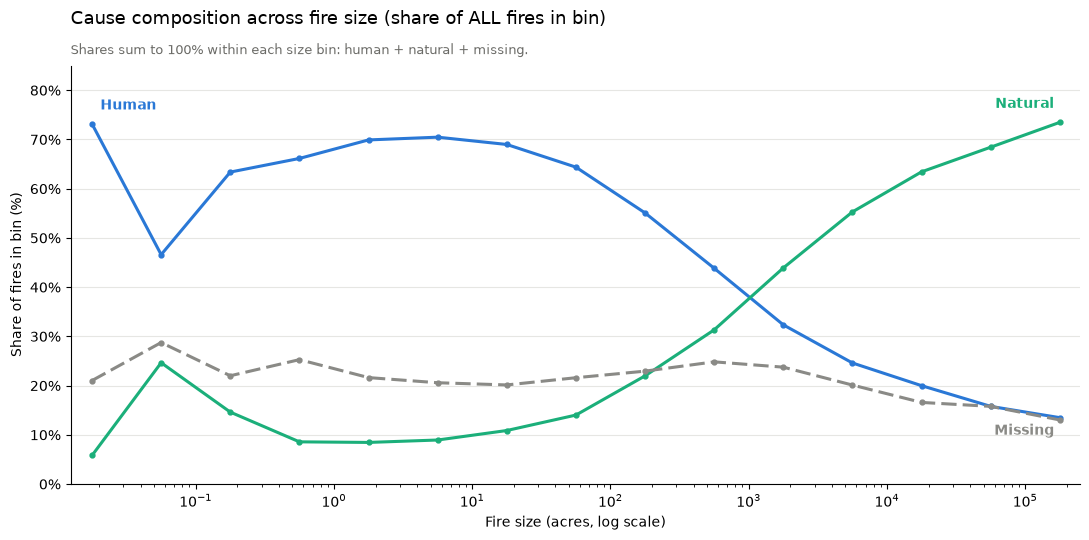

Attributed cause mix: small class n=64,316, large tail n=2,353

                                            small (<0.1 ac) %  tail (>=10k ac) %  shift (tail-small)
NWCG_GENERAL_CAUSE                                                                                  
Debris and open burning                                  32.3                2.8               -29.5
Natural                                                  12.1               78.2                66.1
Arson/incendiarism                                       12.1                4.2                -7.9
Equipment and vehicle use                                16.2                6.1               -10.1
Recreation and ceremony                                   8.7                3.2                -5.5
Misuse of fire by a minor                                 4.2                0.3                -3.9
Smoking                                                   6.2                0.6                -5.6
Railroad operations and mai

In [17]:
# Cause shares across log-spaced fire-size bins, same size edges as the size section
# (0.01 ac floor), so the bins line up with the missing-rate-vs-size curve above.
#
# Collapsed to the Natural/Human binary: that is the grain the bias question operates at, and
# eleven lines converge illegibly at the right edge. "Human" = the eleven specific human causes.
# Denominator is ALL fires in the bin so Missing shows as a third series; Human + Natural +
# Missing = 100%. This differs from the attributed-only shares below, where Human and Natural
# read higher.
#
# Caveat on the Human/Missing boundary: is_missing is keyed on NWCG_GENERAL_CAUSE, so all
# unspecified records land in Missing. FPA-FOD's own NWCG_CAUSE_CLASSIFICATION instead calls
# ~405k of those "Human". This split therefore understates Human and overstates Missing, most
# likely in the small-fire bins where the unspecified records concentrate.
size_cause = df[["FIRE_SIZE", "NWCG_GENERAL_CAUSE", "is_missing"]].copy()
size_cause = size_cause[size_cause["FIRE_SIZE"] >= 0.01]      # match the size-curve floor
size_cause["bin"] = pd.cut(size_cause["FIRE_SIZE"], bins=edges)  # `edges` from the size cell
size_cause["class3"] = np.where(
    size_cause["is_missing"], "Missing",
    np.where(size_cause["NWCG_GENERAL_CAUSE"] == "Natural", "Natural", "Human"),
)

bin_cause = (
    size_cause.groupby(["bin", "class3"], observed=True).size()
    .unstack(fill_value=0)
)
bin_n = bin_cause.sum(axis=1)
bin_share = bin_cause.div(bin_n, axis=0) * 100
STABLE_BIN = bin_n.values >= 100      # suppress thin bins (same rule as the size curve)
centers_b = np.sqrt([iv.left * iv.right for iv in bin_share.index])  # geometric centers
xs = centers_b[STABLE_BIN]

# Three series labelled in place; no legend. Each label sits where its line is farthest
# from the other two.
class_colors = {"Human": "#2a78d6", "Natural": "#1baf7a", "Missing": "#8a8a86"}
label_at = {"Human": 0, "Natural": -1, "Missing": -1}  # 0 = left edge, -1 = right edge

fig, ax = plt.subplots(figsize=(11, 5.5))
for c in ("Human", "Natural", "Missing"):
    if c not in bin_share.columns:
        continue
    y = bin_share[c].values[STABLE_BIN]
    dashed = dict(ls=(0, (5, 2))) if c == "Missing" else {}
    ax.plot(xs, y, color=class_colors[c], lw=2.2, marker="o", ms=3.5, **dashed)
    i = label_at[c]
    # Missing and Natural both end at the right edge, ~1pt apart -- offset Missing downward
    # so the two labels clear each other.
    dy = -13 if c == "Missing" else 8
    ax.annotate(c, (xs[i], y[i]), xytext=(6 if i == 0 else -4, dy),
                textcoords="offset points", ha="left" if i == 0 else "right",
                va="bottom", fontsize=10, fontweight="semibold", color=class_colors[c])

ax.set_xscale("log")
# Title lifted via pad, subtitle just under it.
ax.set_title("Cause composition across fire size (share of ALL fires in bin)",
             fontsize=13, loc="left", pad=30)
ax.text(0, 1.02, "Shares sum to 100% within each size bin: human + natural + missing.",
        transform=ax.transAxes, fontsize=9.5, color="#6a6a66", va="bottom")
ax.set_ylabel("Share of fires in bin (%)")
ax.set_xlabel("Fire size (acres, log scale)")
ax.set_xlim(xs.min() * 0.7, xs.max() * 1.4)
ax.set_ylim(0, 85)   # data tops out ~74%; trimmed from 100 to drop the empty top band
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#e6e6e3", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()

# Save alongside the inline render so the figure can be pulled into the writeup.
IMG = Path("..") / "img" / "cause_composition_by_size.png"
fig.savefig(IMG, dpi=200, bbox_inches="tight", facecolor="white")
print(f"saved -> {IMG}")

plt.show()

# Small-fire class vs large-fire tail, attributed-only -- unaffected by the all-fires
# denominator used in the chart above.
attr_size = size_cause[~size_cause["is_missing"]]

def mix(sub):
    return (sub["NWCG_GENERAL_CAUSE"].value_counts(normalize=True) * 100).round(1)

small = attr_size[attr_size["FIRE_SIZE"] < 0.1]           # the ~29%-missing small class
tail  = attr_size[attr_size["FIRE_SIZE"] >= 10000]        # the ~15%-missing large tail
mix_tbl = pd.DataFrame({
    "small (<0.1 ac) %": mix(small),
    "tail (>=10k ac) %": mix(tail),
}).reindex(cause_order).dropna(how="all")
mix_tbl["shift (tail-small)"] = (mix_tbl["tail (>=10k ac) %"]
                                 - mix_tbl["small (<0.1 ac) %"]).round(1)
print(f"Attributed cause mix: small class n={len(small):,}, large tail n={len(tail):,}\n")
print(mix_tbl.to_string())

# Same split at the three-way grain on ALL fires, matching the chart's denominator.
def mix3(sub):
    return (sub["class3"].value_counts(normalize=True) * 100).round(1)

all_small = size_cause[size_cause["FIRE_SIZE"] < 0.1]
all_tail  = size_cause[size_cause["FIRE_SIZE"] >= 10000]
print("\nThree-way split, share of ALL fires (chart denominator):")
print(pd.DataFrame({"small (<0.1 ac) %": mix3(all_small),
                    "tail (>=10k ac) %": mix3(all_tail)})
      .reindex(["Human", "Natural", "Missing"]).to_string())


**Finding.** This probe comes back **positive for a real effect**: small and large fires have
radically different cause mixes, so the size-concentration of missingness is not compositionally
neutral. But the direction makes it harmless to the deliverable.

**Small and large fires are almost inverse in cause.** The mix does not drift with size, it flips:

- **Natural:** 12% of the small class (<0.1 ac) vs **78%** of the large tail (≥10k ac) — a +66-point
  swing. The acre-dominant tail is overwhelmingly lightning.
- **Debris/open burning:** 32% of small fires vs **3%** of the tail — a −30-point swing.
- **Every human cause shrinks in the tail** (Equipment −10, Arson −8, Smoking −6, Recreation −6).

**So the bucket is not a random draw across causes — but what it under-samples is the small, human,
Debris-heavy end, not Natural.** This is the one place in the notebook where "roughly random across
causes" fails.

**It bites the count view, which the project does not use.** A naïve count of attributed causes
would slightly over-represent Natural and under-represent Debris and human causes. The project
weights by burned area, the acre total is driven by the Natural-heavy tail, and that tail is the
best-attributed part of the record (~15% missing). Debris dominates small fires that contribute
almost nothing to acres, so the acre-weighted composition barely inherits the bias.

**It points away from Natural**, agreeing with the other two probes. Natural is the *least*
size-exposed cause here — 78% of the best-attributed tail.

The large tail is n=2,353 attributed fires, so sub-1% rows (Firearms 0.0%→0.6%, Fireworks, Other)
are noise. The headline — Natural up sharply, Debris down sharply, all human causes down in the
tail — is robust to that.

## Section summary — does the Missing bucket hide particular causes?

Three probes looked for the footprints a non-random draw would leave in the attributed record.

| Probe | Confound handled | Natural | Verdict on a random draw |
|---|---|---|---|
| **Over time** | detrended, removing calendar drift | flat (r ≈ −0.02) | no year-to-year hiding; raw correlation confirmed as a trap |
| **Within region×season** | region & season fixed, drift preserved | flat by count (r ≈ +0.02); weak acre negative (−0.20, ~half from Alaska) | no cause shows the hiding signature by count |
| **By fire size** | none needed (within attributed fires) | least exposed (78% of the best-attributed tail) | **not** random by size — small human/Debris fires under-sampled |

**By count, all three angles find no evidence the bucket selectively hides Natural fires.** The
acre-weighted within-cell probe is the one exception, at −0.20; roughly half of that is a single
edge-case cell (`AK|Summer`, r = −0.61, ~19% of the acre weight), and removing Alaska halves it to
−0.10. The count result is the reliable read, and the within-region×season probe is the decisive
one — it controls region and season *and* preserves gradual drift, so slow absorption would have
shown. The Natural→Missing absorption question is left **weakly open, not closed**.

**The one clear non-randomness is size-selectivity, and it points away from the product's target.**
Missing under-samples the small, human, Debris-heavy end (Debris 32% of small fires vs 3% of the
large tail; Natural the inverse). That bias lands on the **count-weighted** composition, while the
project weights by **burned area** — driven by the Natural-heavy tail, the best-attributed part of
the record.

**What this licenses.** Build the model on the cause-attributed record and treat Missing as "not a
label" rather than a class to predict. Within a region×season cell the attributed count draw is
unbiased, and the size bias misses the acre-weighted target. Two guardrails remain, neither a
reason to re-include unattributed records:

1. **Precision, not bias.** Missingness is concentrated by geography and rising over time, so
   high-missing cells — disproportionately recent western region-seasons, exactly the cells a
   next-season forecast leans on — have their target estimated from a thinner sample. Carry each
   cell's missing rate as a data-quality covariate so low-attribution cells are down-weighted.
2. **The acre/edge-case tilt.** The weak acre-weighted Natural negative concentrates in the
   huge-fire acre tail and in Alaska specifically.

These are observational associations, not proofs of exact cause-neutrality, and the region grain
here is STATE rather than the project's ecoregion grain.